# Graphiques pour la deuxième étude avec OpenAlex

## 1. Library Import 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Data Import

In [2]:
df = pd.read_csv('openalex_vietnam_new_year_to_use.csv')


In [3]:
display (df)

,id,title,publication_year,language,type,institution_countries,institutions,domains,fields,subfields,topics,primary_topic_name,primary_topic_field_name,primary_topic_subfield_name,primary_topic_domain_name,referenced_ids,referenced_count,lang_type,referenced_ids_internal
0,https://openalex.org/W3024878631,The long-run impact of bombing Vietnam,2010,en,article,GB; US,Centre for Economic Policy Research; Universit...,Geography; Political science; Economics; Socio...,Development economics; Economic growth; Socioe...,Vietnam War; Poverty; Population; Instrumental...,Strategic bombing,"Defense, Military, and Policy Studies","Economics, Econometrics and Finance",Economics and Econometrics,Social Sciences,https://openalex.org/W2171656257; https://open...,79,américain,NaN
1,https://openalex.org/W2133466515,Psychophysiologic Assessment of Posttraumatic ...,1987,en,article,US,United States Department of Veterans Affairs,Psychology; Geography,Clinical psychology; Psychiatry; Archaeology,Posttraumatic stress; Vietnam War,NaN,Posttraumatic Stress Disorder Research,Psychology,Clinical Psychology,Social Sciences,https://openalex.org/W1971449933; https://open...,18,américain,NaN
2,https://openalex.org/W3123011427,Interfirm Relationships and Informal Credit in...,1999,en,article,US,"Stanford University; University of California,...",Business; Political science,Finance; Law,Default; Enforcement,NaN,Working Capital and Financial Performance,"Business, Management and Accounting",Accounting,Social Sciences,https://openalex.org/W3123550268; https://open...,32,américain,NaN
3,https://openalex.org/W2041685217,Learning and foreign policy: sweeping a concep...,1994,en,article,US,"Rutgers, The State University of New Jersey",History; Political science; Sociology,Economic history; Political economy; Law; Clas...,Politics; German; Paradise; Mythology; Vietnam...,Foreign policy,International Relations and Foreign Policy,Social Sciences,Political Science and International Relations,Social Sciences,https://openalex.org/W5855877; https://openale...,140,américain,"['https://openalex.org/W2048335617', 'https://..."
4,https://openalex.org/W2049228636,The Pretty Prudent Public: Post Post-Vietnam A...,1992,en,article,US,"University of California, Davis",Political science,Law,Vietnam War; Politics,Public opinion,Military and Defense Studies,Social Sciences,Political Science and International Relations,Social Sciences,https://openalex.org/W183747230; https://opena...,18,américain,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15222,https://openalex.org/W4323244376,Constitution et passé,2023,fr,book,FR,Aix-Marseille Université,Philosophy; Art; Political science,Humanities; Law,Constitution,NaN,European Political History Analysis,Arts and Humanities,History,Social Sciences,https://openalex.org/W1964769226; https://open...,16,français,NaN
15223,https://openalex.org/W2753079631,"""I Am Contemporary!"": The Life and Times of Pe...",1996,en,dissertation,US,Louisiana State University Agricultural Center,Art; History; Sociology; Geography,Art history; Visual arts; Media studies; Carto...,Performance art; Heaven,NaN,Music History and Culture,Arts and Humanities,Music,Social Sciences,https://openalex.org/W6828547186; https://open...,35,américain,NaN
15224,https://openalex.org/W2806220170,Senior citizens as an emerging force in Americ...,1990,en,article,US,The Ohio State University,Political science; Sociology,Public relations; Political economy; Law,Politics,NaN,Social Policy and Reform Studies,Social Sciences,Political Science and International Relations,Social Sciences,NaN,0,américain,NaN
15225,https://openalex.org/W4312622443,Secouer le lecteur. Perspective narrative et f...,2022,fr,book-chapter,BR; GB; PL; US,Adam Mickiewicz University in Poznań; Centro U...,Art; History,Literature; Visual arts,Narrative; Perspective (graphical),NaN,Narrative Theory and Analysis,Arts and Humanities,Literature and Literary Theory,Social Sciences,https:/

## 3. Data Manipulation

In [4]:
def detect_fr_usa(value):

    s = str(value)

    has_fr = "FR" in s
    has_usa = "US" in s
    has_vn = "VN" in s

    if has_vn:
        if has_fr and has_usa:
          return "FR-US-VN"
        elif has_fr:
            return "FR-VN"
        elif has_usa:
            return "US-VN"
        else:
            return "VN"

    elif has_fr and has_usa:
        return "FR-US"
    
    elif has_usa:
        return "US"
    elif has_fr:
        return "FR"
    
    else:
        return None  

df["FR-US"] = df["institution_countries"].apply(detect_fr_usa)


## 4. Data Visualisation

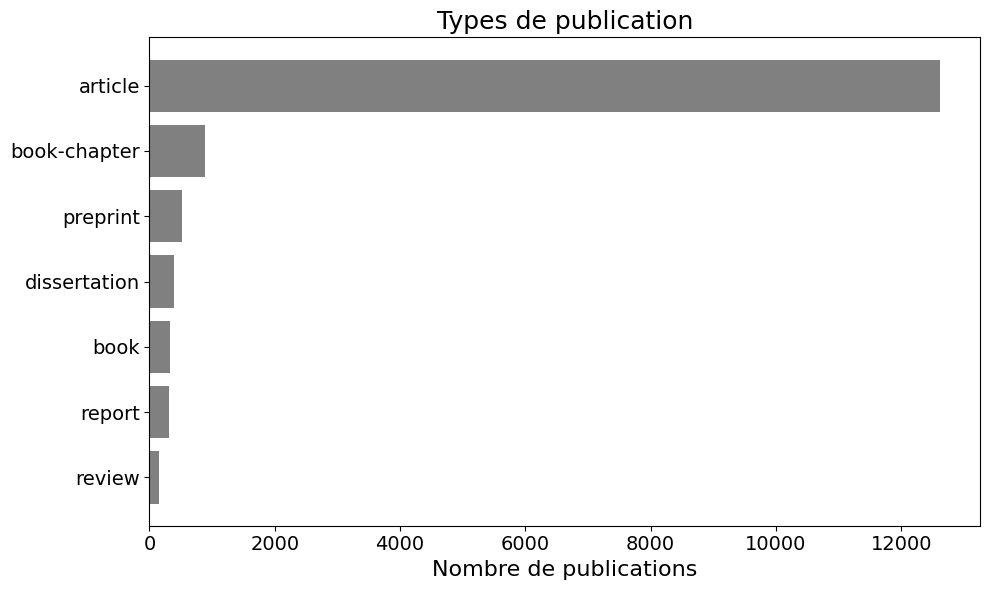

In [5]:

df_exploded = df.assign(
    type=df['type'].str.split(';')
).explode('type')
df_exploded['type'] = df_exploded['type'].str.strip()


counts = df_exploded['type'].value_counts()


top10 = counts.head(10)


title_fs = 18
label_fs = 16
tick_fs = 14


plt.figure(figsize=(10, 6))

plt.barh(top10.index, top10.values, color="grey")
plt.xlabel("Nombre de publications", fontsize=label_fs)
plt.title("Types de publication", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()


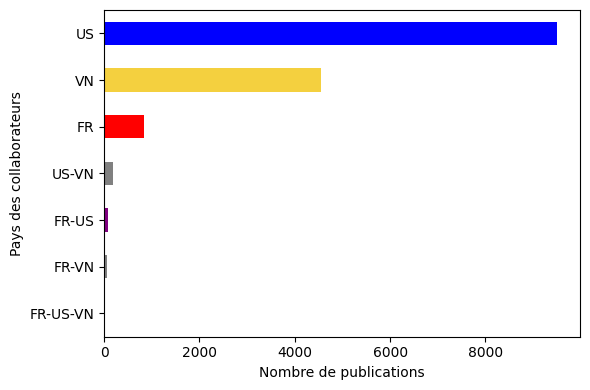

In [6]:
counts = df["FR-US"].value_counts()


colors = {
    "FR": "red",
    "US": "blue",
    "FR-US": "purple",
    "VN": "#F4D03F",
    "FR-VN": "grey",
    "US-VN": "grey",
    "FR-US-VN": "grey"
}

bar_colors = [colors[cat] for cat in counts.index]


plt.figure(figsize=(6, 4))
counts.plot(kind="barh", color=bar_colors)

plt.ylabel("Pays des collaborateurs")
plt.xlabel("Nombre de publications")


plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


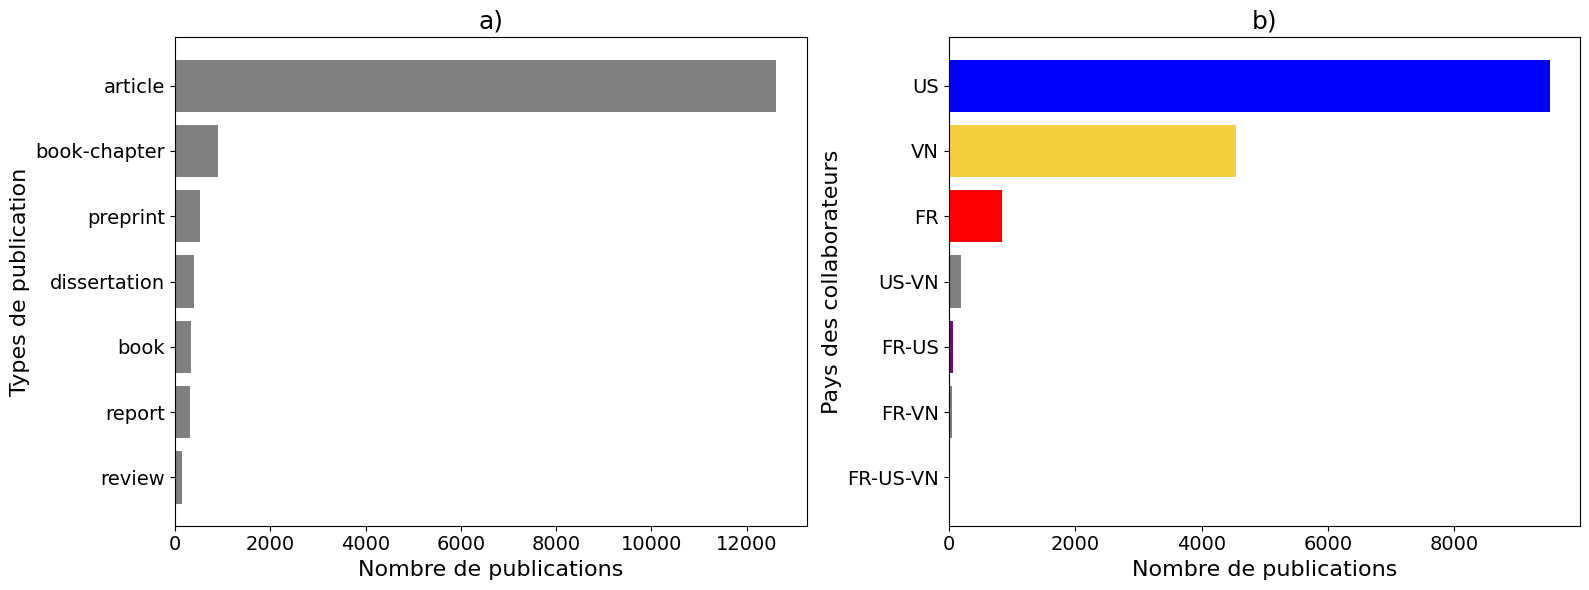

In [7]:
title_fs = 18
label_fs = 16
tick_fs = 14


fig, axes = plt.subplots(1, 2, figsize=(16, 6))



df_exploded = df.assign(
    type=df["type"].str.split(";")
).explode("type")
df_exploded["type"] = df_exploded["type"].str.strip()

counts_type = df_exploded["type"].value_counts()
top10 = counts_type.head(10)

axes[0].barh(top10.index, top10.values, color="grey")
axes[0].set_xlabel("Nombre de publications", fontsize=label_fs)
axes[0].set_ylabel("Types de publication", fontsize=label_fs)
axes[0].set_title("a)", fontsize=title_fs)
axes[0].tick_params(axis="x", labelsize=tick_fs)
axes[0].tick_params(axis="y", labelsize=tick_fs)
axes[0].invert_yaxis()


counts_collab = df["FR-US"].value_counts()

colors = {
    "FR": "red",
    "US": "blue",
    "FR-US": "purple",
    "VN": "#F4D03F",
    "FR-VN": "grey",
    "US-VN": "grey",
    "FR-US-VN": "grey"
}
bar_colors = [colors.get(cat, "grey") for cat in counts_collab.index]

axes[1].barh(counts_collab.index, counts_collab.values, color=bar_colors)
axes[1].set_xlabel("Nombre de publications", fontsize=label_fs)
axes[1].set_ylabel("Pays des collaborateurs", fontsize=label_fs)
axes[1].set_title("b)", fontsize=title_fs)
axes[1].tick_params(axis="x", labelsize=tick_fs)
axes[1].tick_params(axis="y", labelsize=tick_fs)
axes[1].invert_yaxis()


plt.tight_layout()
plt.show()


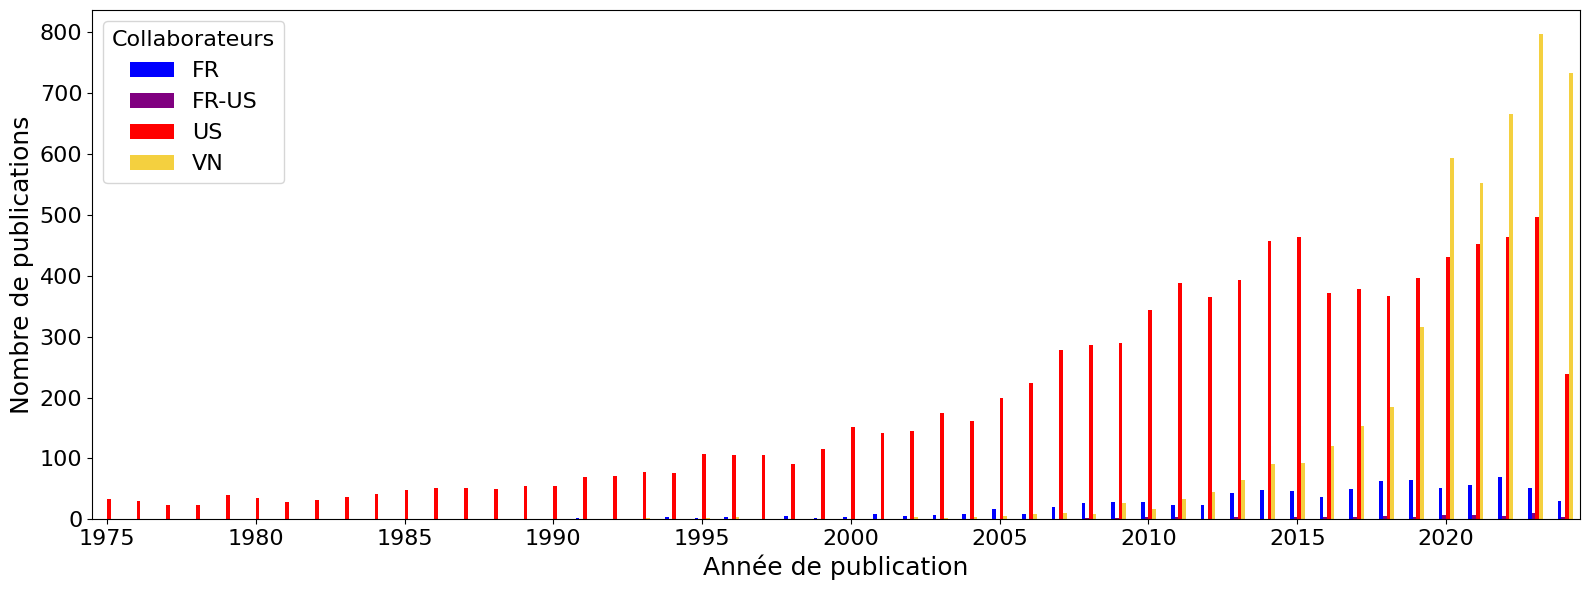

In [8]:
title_fs = 22
label_fs = 18
tick_fs = 16
legend_fs = 16


categories = ["FR", "US", "FR-US", "VN"]
df_filtered = df[df["FR-US"].isin(categories)]


counts = (
    df_filtered
    .groupby(["publication_year", "FR-US"])
    .size()
    .unstack(fill_value=0)
)

colors = {
    "FR": "blue",
    "FR-US": "purple",
    "US": "red",
    "VN": "#F4D03F"
}


ax = counts.plot(
    kind="bar",
    figsize=(16, 6),
    color=[colors[col] for col in counts.columns]
)

ax.set_xlabel("Année de publication", fontsize=label_fs)
ax.set_ylabel("Nombre de publications", fontsize=label_fs)
ax.set_title(
    "",
    fontsize=title_fs
)

ax.legend(
    title="Collaborateurs",
    fontsize=legend_fs,
    title_fontsize=legend_fs
)


years = counts.index
ticks = [i for i, year in enumerate(years) if year % 5 == 0]

ax.set_xticks(ticks)
ax.set_xticklabels(
    [years[i] for i in ticks],
    rotation=0,
    fontsize=tick_fs
)

ax.tick_params(axis="y", labelsize=tick_fs)

plt.tight_layout()
plt.show()


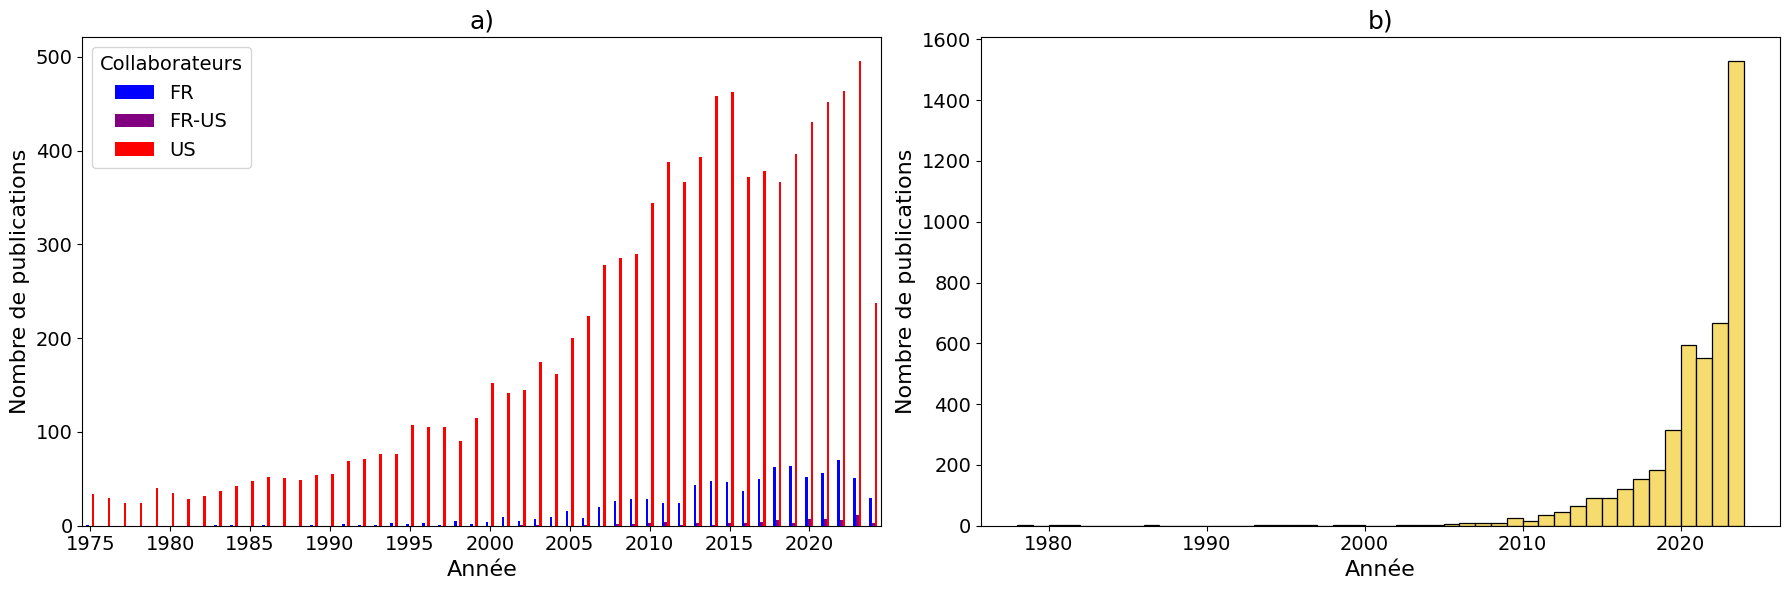

In [9]:
title_fs = 18
label_fs = 16
tick_fs = 14
legend_fs = 14


fig, axes = plt.subplots(1, 2, figsize=(18, 6))


categories = ["FR", "US", "FR-US"]
df_filtered_1 = df[df["FR-US"].isin(categories)]

counts = (
    df_filtered_1
    .groupby(["publication_year", "FR-US"])
    .size()
    .unstack(fill_value=0)
)

colors = {
    "FR": "blue",
    "FR-US": "purple",
    "US": "red"
}

counts.plot(
    kind="bar",
    ax=axes[0],
    color=[colors[col] for col in counts.columns]
)

axes[0].set_xlabel("Année", fontsize=label_fs)
axes[0].set_ylabel("Nombre de publications", fontsize=label_fs)
axes[0].set_title(
    "a)",
    fontsize=title_fs
)

years = counts.index
ticks = [i for i, year in enumerate(years) if year % 5 == 0]

axes[0].set_xticks(ticks)
axes[0].set_xticklabels([years[i] for i in ticks], rotation=0, fontsize=tick_fs)

axes[0].tick_params(axis="y", labelsize=tick_fs)
axes[0].legend(title="Collaborateurs", fontsize=legend_fs, title_fontsize=legend_fs)



categories = ["VN"]
df_filtered_2 = df[df["FR-US"].isin(categories)]

sns.histplot(
    data=df_filtered_2,
    x="publication_year",
    binwidth=1,
    color="#F4D03F",
    edgecolor="black",
    ax=axes[1]
)

axes[1].set_xlabel("Année", fontsize=label_fs)
axes[1].set_ylabel("Nombre de publications", fontsize=label_fs)
axes[1].set_title(
    "b)",
    fontsize=title_fs
)

axes[1].tick_params(axis="x", labelsize=tick_fs)
axes[1].tick_params(axis="y", labelsize=tick_fs)


plt.tight_layout()
plt.show()


In [10]:
df_exploded = df.assign(
    field=df['fields'].str.split(';')
).explode('field')


df_exploded['field'] = df_exploded['field'].str.strip()


df_fr = df_exploded[df_exploded['FR-US'] == 'FR']
df_us = df_exploded[df_exploded['FR-US'] == 'US']

counts_fr = df_fr['field'].value_counts()
counts_us = df_us['field'].value_counts()


prop_fr = counts_fr / counts_fr.sum()
prop_us = counts_us / counts_us.sum()


top10_fr = prop_fr.head(10)
top10_us = prop_us.head(10)

top10_fr, top10_us


(field
 Law                0.138194
 Humanities         0.093217
 Archaeology        0.083424
 Linguistics        0.046427
 Ethnology          0.036271
 Economic growth    0.030105
 Finance            0.029742
 Ancient history    0.025753
 Art history        0.023214
 Literature         0.020675
 Name: count, dtype: float64,
 field
 Law                  0.186376
 Archaeology          0.060120
 Linguistics          0.045654
 Gender studies       0.030466
 Political economy    0.028000
 Social psychology    0.027218
 Economic growth      0.026797
 Epistemology         0.025504
 Finance              0.024331
 Literature           0.023218
 Name: count, dtype: float64)

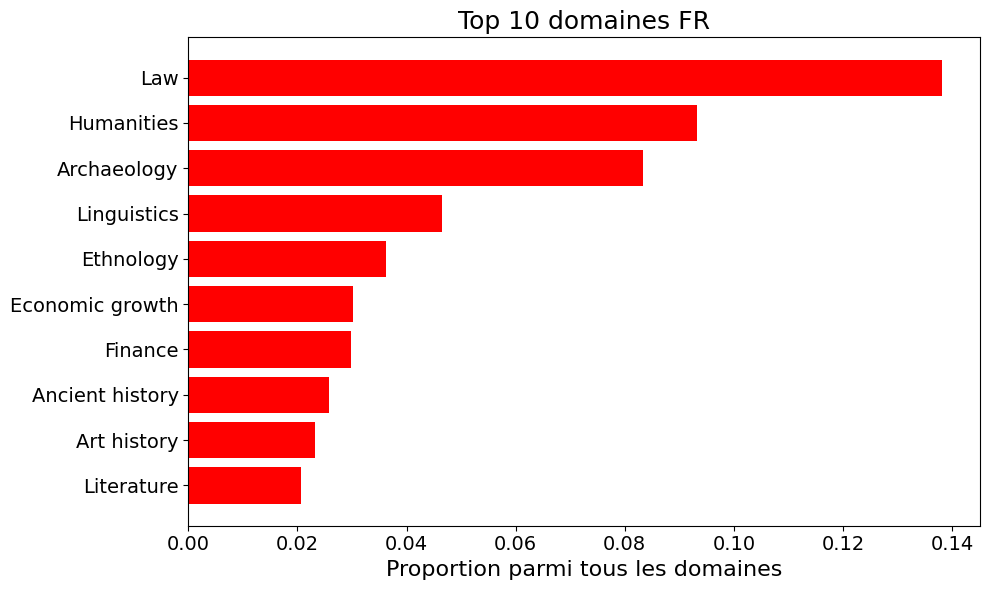

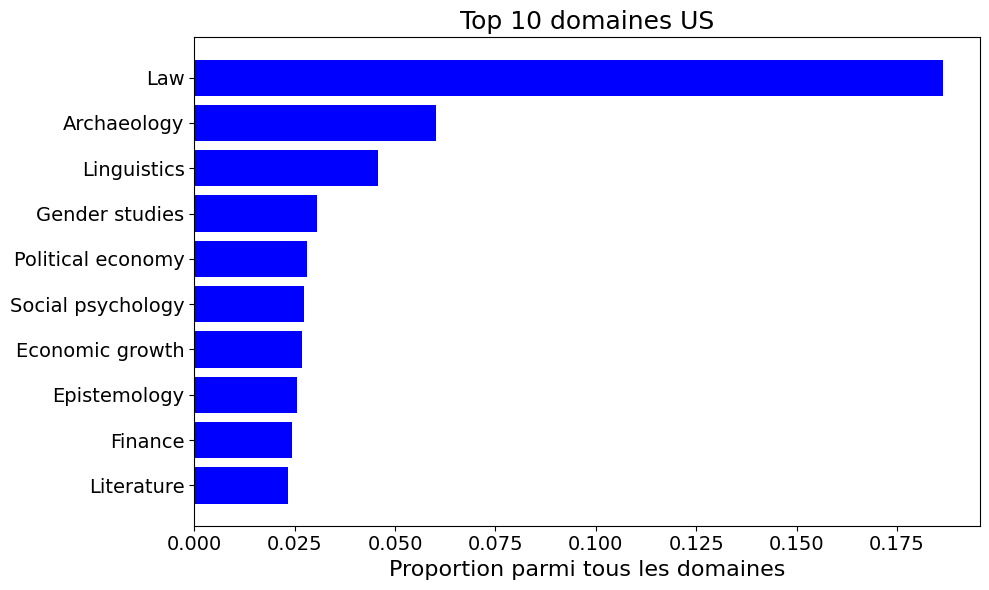

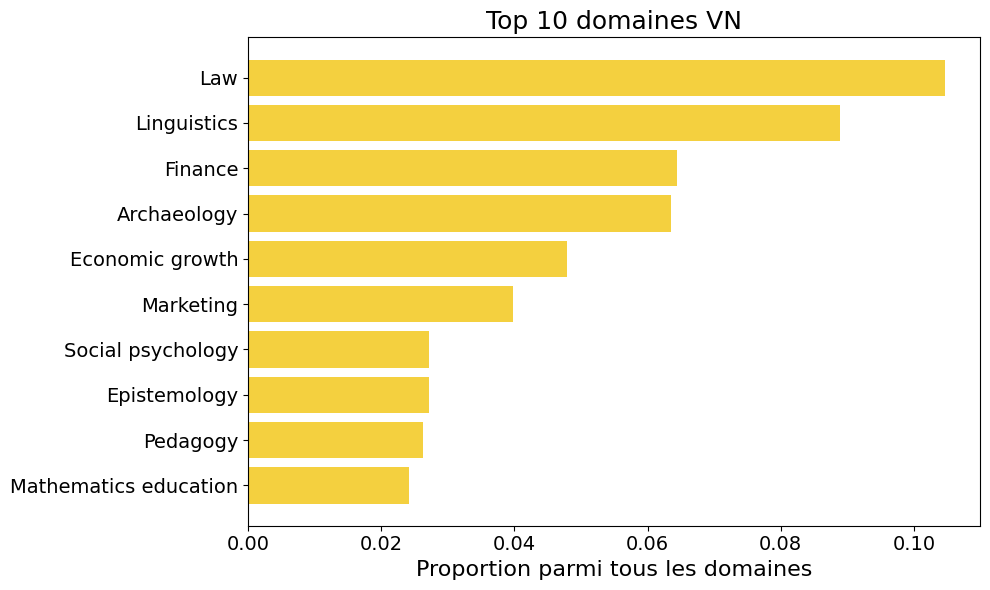

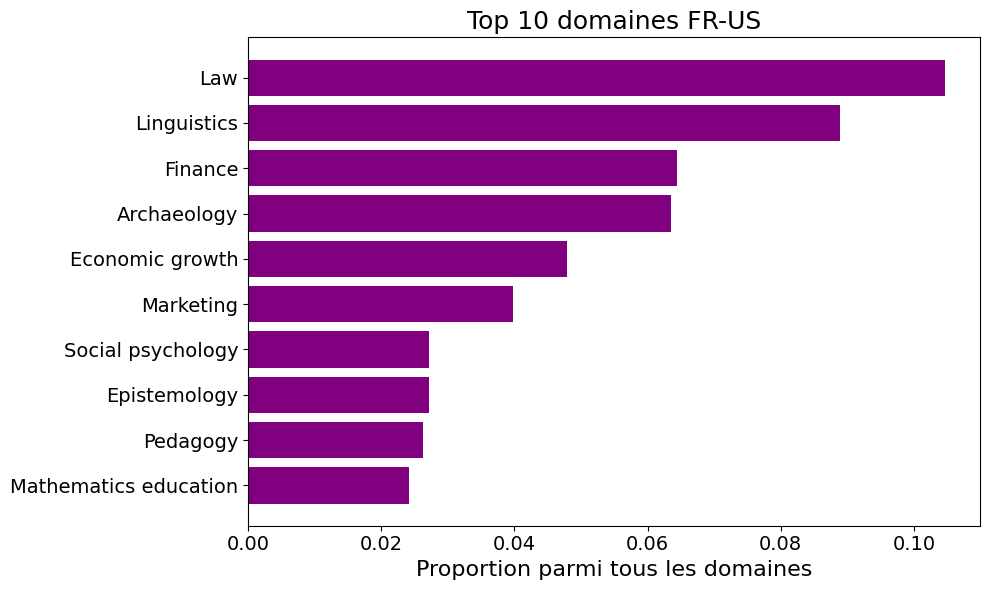

In [11]:
df_exploded = df.assign(
    field=df['fields'].str.split(';')
).explode('field')
df_exploded['field'] = df_exploded['field'].str.strip()


df_fr = df_exploded[df_exploded['FR-US'] == 'FR']
df_us = df_exploded[df_exploded['FR-US'] == 'US']
df_vn = df_exploded[df_exploded['FR-US'] == 'VN']
df_fr_us = df_exploded[df_exploded['FR-US'] == 'FR-US']


counts_fr = df_fr['field'].value_counts()
counts_us = df_us['field'].value_counts()
counts_vn = df_vn['field'].value_counts()
counts_fr_us = df_vn['field'].value_counts()


prop_fr = (counts_fr / counts_fr.sum()).sort_values(ascending=False)
prop_us = (counts_us / counts_us.sum()).sort_values(ascending=False)
prop_vn = (counts_vn / counts_vn.sum()).sort_values(ascending=False)
prop_fr_us = (counts_fr_us / counts_fr_us.sum()).sort_values(ascending=False)


top10_fr = prop_fr.head(10)
top10_us = prop_us.head(10)
top10_vn = prop_vn.head(10)
top10_fr_us = prop_fr_us.head(10)

title_fs = 18
label_fs = 16
tick_fs = 14


plt.figure(figsize=(10, 6))

plt.barh(top10_fr.index, top10_fr.values, color="red")
plt.xlabel("Proportion parmi tous les domaines", fontsize=label_fs)
plt.title("Top 10 domaines FR", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))

plt.barh(top10_us.index, top10_us.values, color="blue")
plt.xlabel("Proportion parmi tous les domaines", fontsize=label_fs)
plt.title("Top 10 domaines US", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))

plt.barh(top10_vn.index, top10_vn.values, color="#F4D03F")
plt.xlabel("Proportion parmi tous les domaines", fontsize=label_fs)
plt.title("Top 10 domaines VN", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.barh(top10_fr_us.index, top10_fr_us.values, color="purple")
plt.xlabel("Proportion parmi tous les domaines", fontsize=label_fs)
plt.title("Top 10 domaines FR-US", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


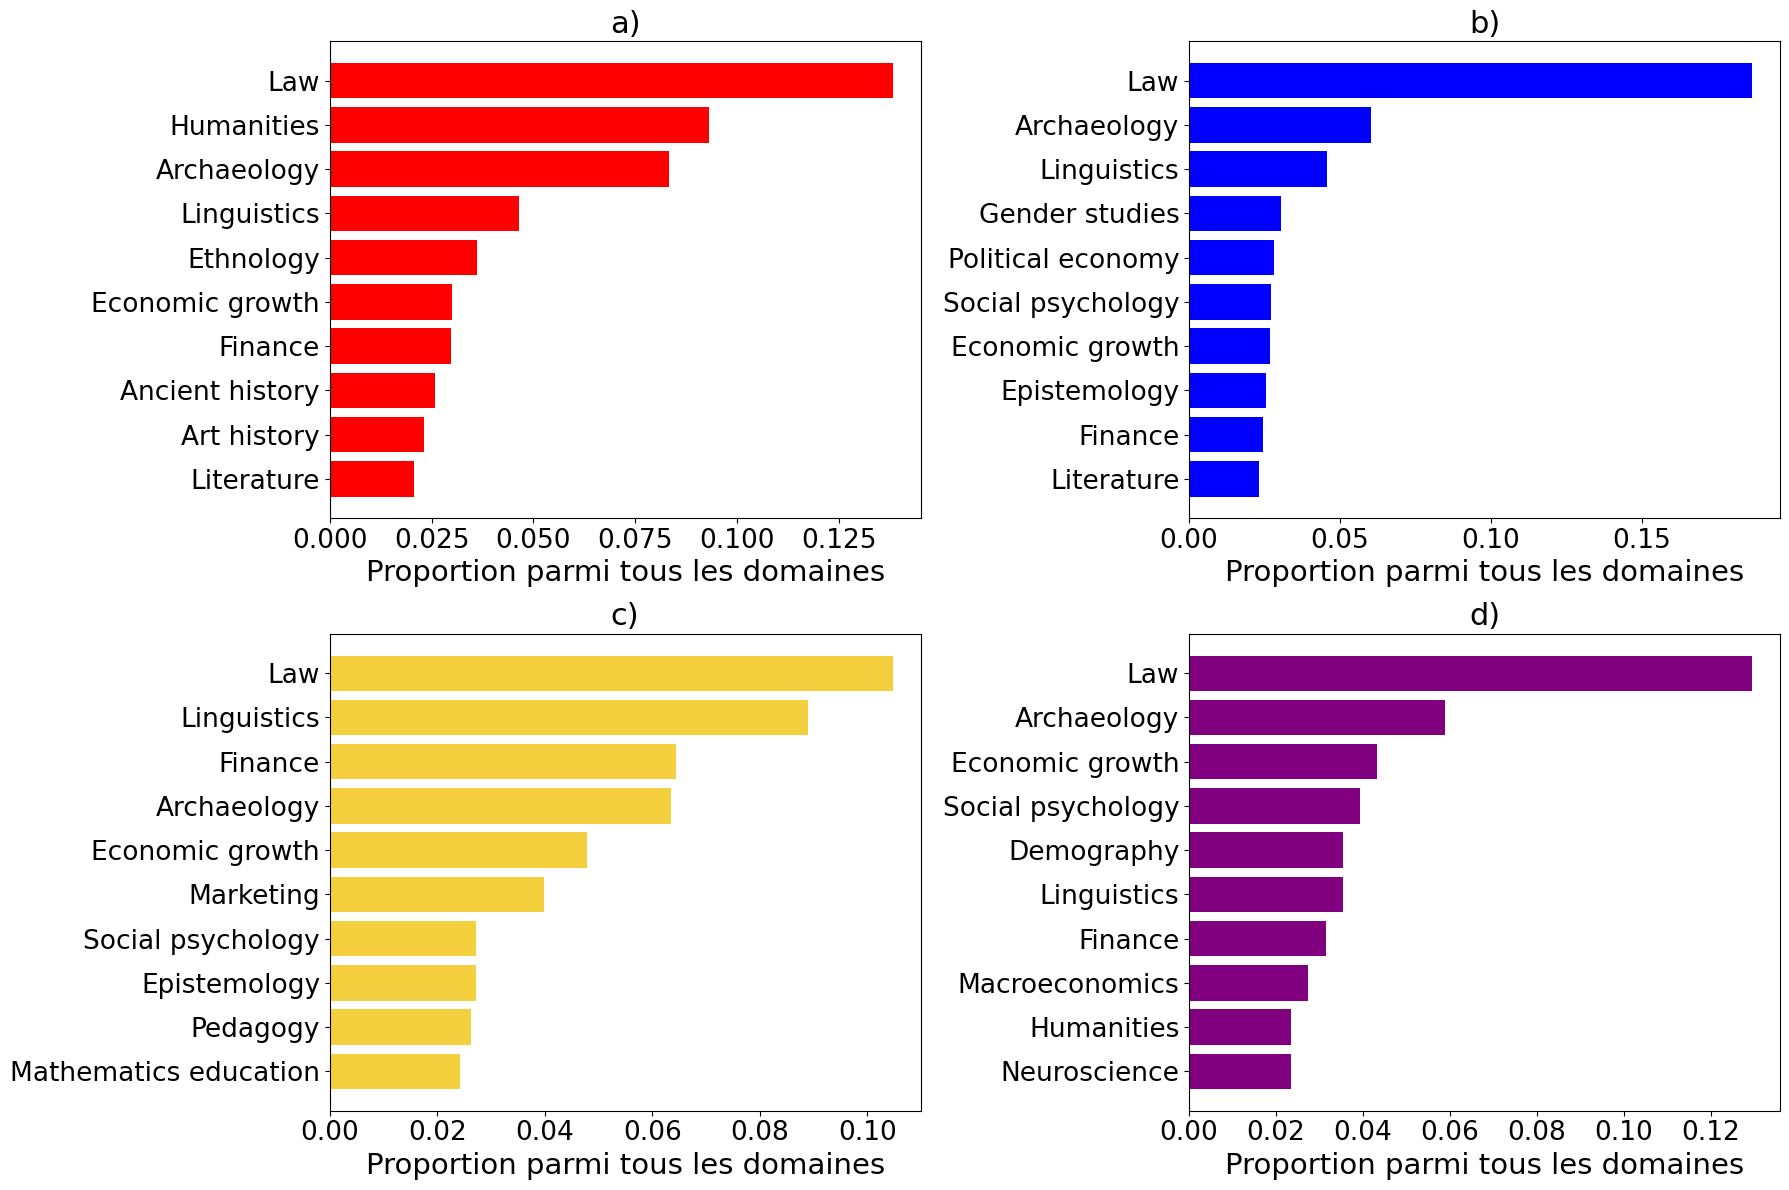

In [12]:
df_exploded = df.assign(
    field=df["fields"].str.split(";")
).explode("field")
df_exploded["field"] = df_exploded["field"].str.strip()


df_fr = df_exploded[df_exploded["FR-US"] == "FR"]
df_us = df_exploded[df_exploded["FR-US"] == "US"]
df_vn = df_exploded[df_exploded["FR-US"] == "VN"]
df_fr_us = df_exploded[df_exploded["FR-US"] == "FR-US"]


counts_fr = df_fr["field"].value_counts()
counts_us = df_us["field"].value_counts()
counts_vn = df_vn["field"].value_counts()
counts_fr_us = df_fr_us["field"].value_counts() 


prop_fr = (counts_fr / counts_fr.sum()).sort_values(ascending=False)
prop_us = (counts_us / counts_us.sum()).sort_values(ascending=False)
prop_vn = (counts_vn / counts_vn.sum()).sort_values(ascending=False)
prop_fr_us = (counts_fr_us / counts_fr_us.sum()).sort_values(ascending=False)


top10_fr = prop_fr.head(10)
top10_us = prop_us.head(10)
top10_vn = prop_vn.head(10)
top10_fr_us = prop_fr_us.head(10)


title_fs = 22
label_fs = 21
tick_fs = 19


fig, axes = plt.subplots(2, 2, figsize=(18, 12))

plots = [
    (axes[0, 0], top10_fr, "a)", "red"),
    (axes[0, 1], top10_us, "b)", "blue"),
    (axes[1, 0], top10_vn, "c)", "#F4D03F"),
    (axes[1, 1], top10_fr_us, "d)", "purple"),
]

for ax, data, title, color in plots:
    ax.barh(data.index, data.values, color=color)
    ax.set_title(title, fontsize=title_fs)
    ax.set_xlabel("Proportion parmi tous les domaines", fontsize=label_fs)
    ax.tick_params(axis="x", labelsize=tick_fs)
    ax.tick_params(axis="y", labelsize=tick_fs)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


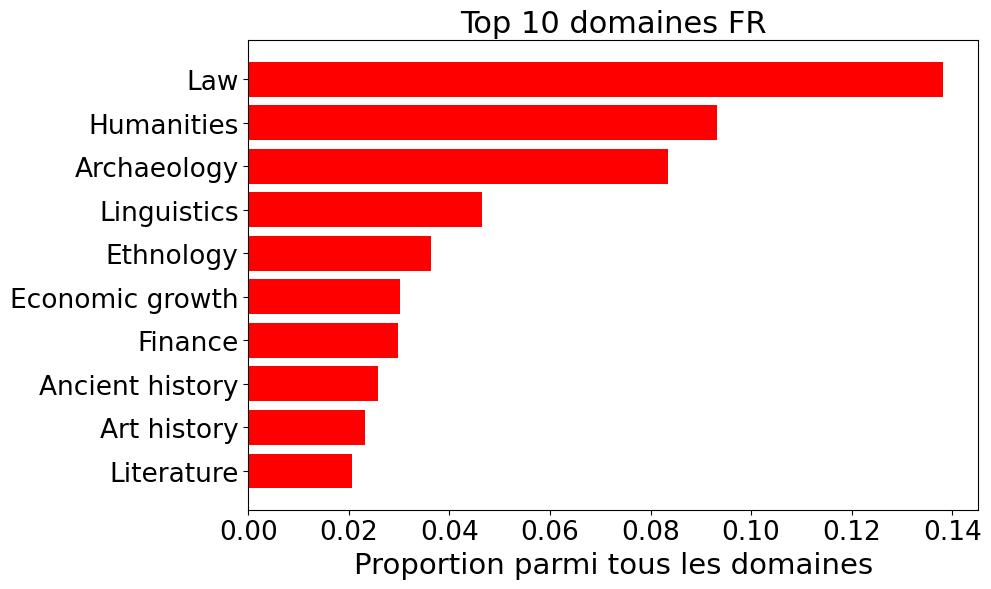

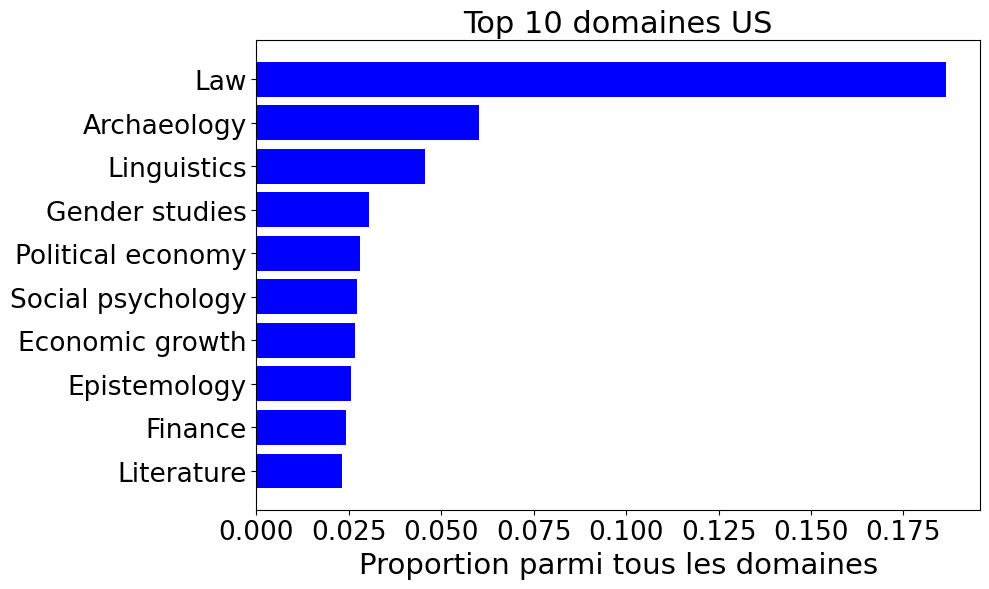

In [13]:
plt.figure(figsize=(10, 6))

plt.barh(top10_fr.index, top10_fr.values, color="red")
plt.xlabel("Proportion parmi tous les domaines", fontsize=label_fs)
plt.title("Top 10 domaines FR", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.barh(top10_us.index, top10_us.values, color="blue")
plt.xlabel("Proportion parmi tous les domaines", fontsize=label_fs)
plt.title("Top 10 domaines US", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Primary Topic

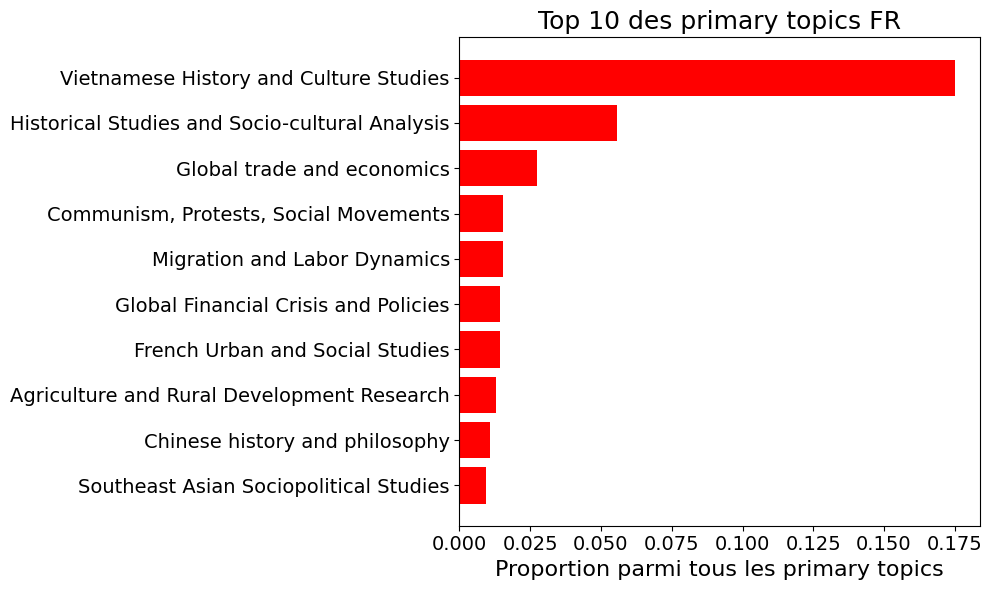

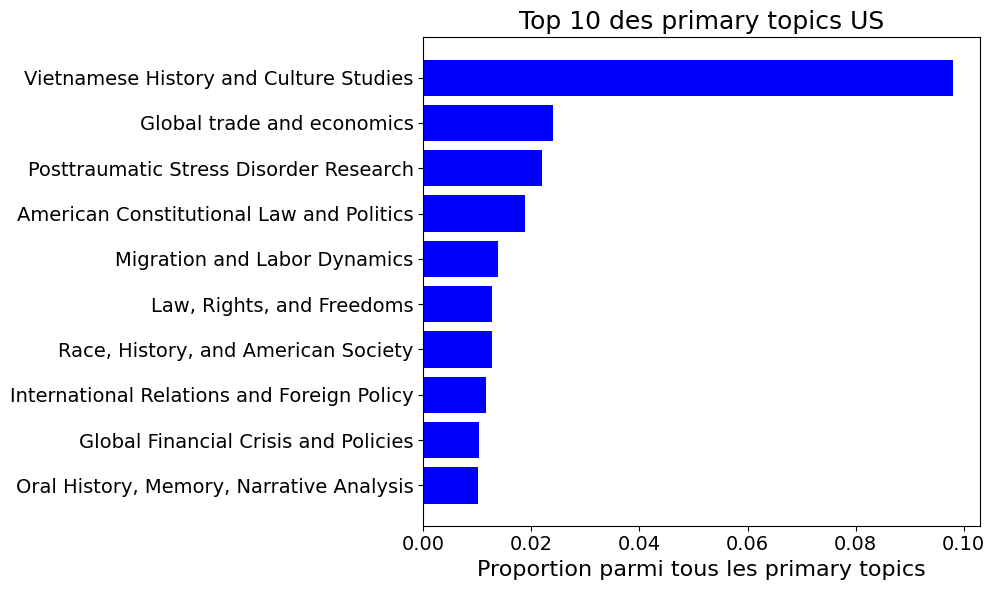

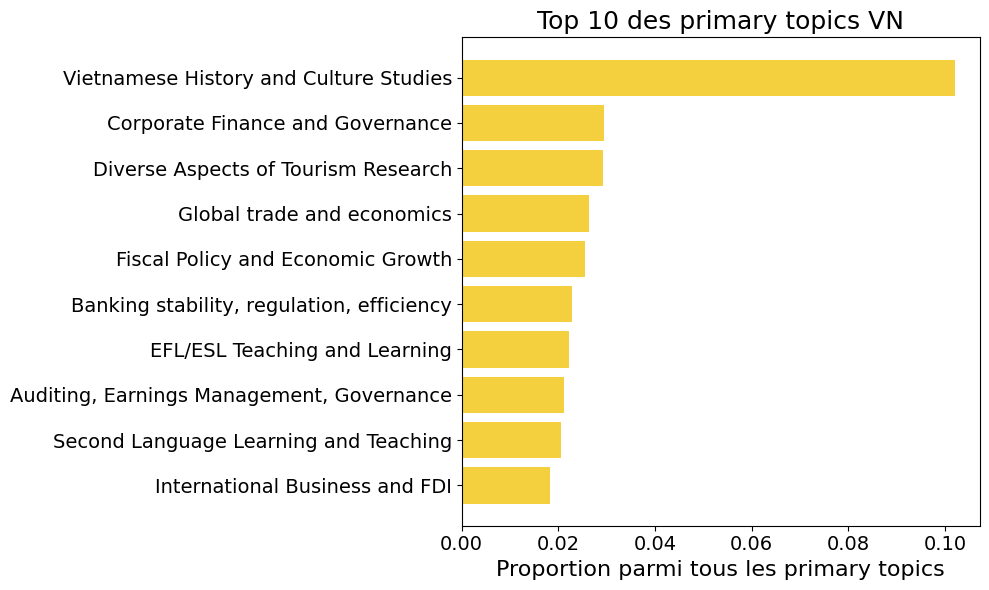

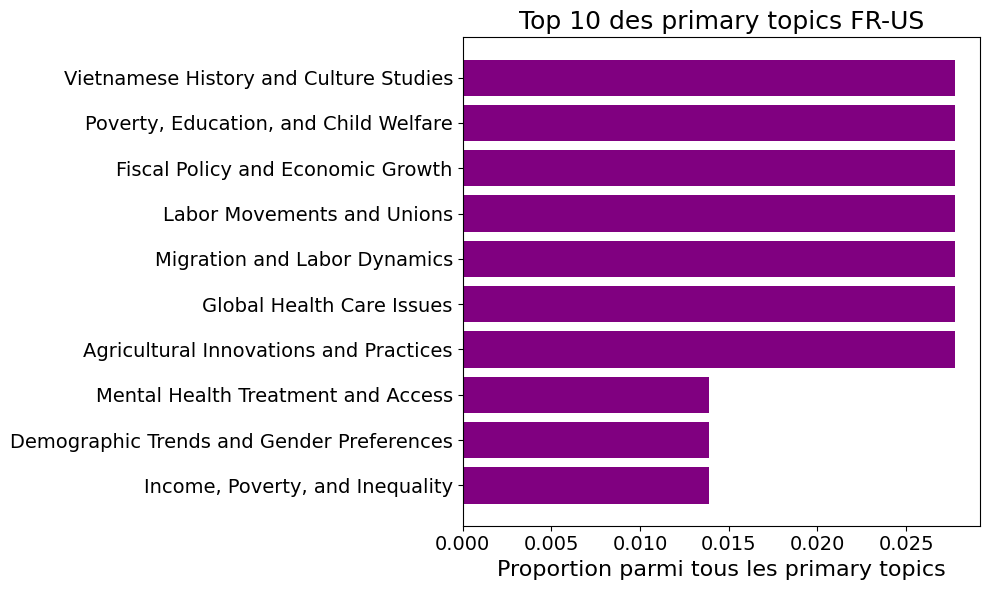

In [14]:
df['primary_topic_name_clean'] = df['primary_topic_name'].fillna("").str.strip()

df_fr = df[df['FR-US'] == 'FR']
df_us = df[df['FR-US'] == 'US']
df_vn = df[df['FR-US'] == 'VN']
df_fr_us = df[df['FR-US'] == 'FR-US']

counts_fr = df_fr['primary_topic_name_clean'].value_counts()
counts_us = df_us['primary_topic_name_clean'].value_counts()
counts_vn = df_vn['primary_topic_name_clean'].value_counts()
counts_fr_us = df_fr_us['primary_topic_name_clean'].value_counts()

prop_fr = (counts_fr / counts_fr.sum()).sort_values(ascending=False)
prop_us = (counts_us / counts_us.sum()).sort_values(ascending=False)
prop_vn = (counts_vn / counts_vn.sum()).sort_values(ascending=False)
prop_fr_us = (counts_fr_us / counts_fr_us.sum()).sort_values(ascending=False)


top10_fr = prop_fr.head(10)
top10_us = prop_us.head(10)
top10_vn = prop_vn.head(10)
top10_fr_us = prop_fr_us.head(10)

title_fs = 18
label_fs = 16
tick_fs = 14


plt.figure(figsize=(10, 6))

plt.barh(top10_fr.index, top10_fr.values, color="red")
plt.xlabel("Proportion parmi tous les primary topics", fontsize=label_fs)
plt.title("Top 10 des primary topics FR", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.barh(top10_us.index, top10_us.values, color="blue")
plt.xlabel("Proportion parmi tous les primary topics", fontsize=label_fs)
plt.title("Top 10 des primary topics US", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))

plt.barh(top10_vn.index, top10_vn.values, color="#F4D03F")
plt.xlabel("Proportion parmi tous les primary topics", fontsize=label_fs)
plt.title("Top 10 des primary topics VN", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))

plt.barh(top10_fr_us.index, top10_fr_us.values, color="purple")
plt.xlabel("Proportion parmi tous les primary topics", fontsize=label_fs)
plt.title("Top 10 des primary topics FR-US", fontsize=title_fs)

plt.xticks(fontsize=tick_fs)
plt.yticks(fontsize=tick_fs)

plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()



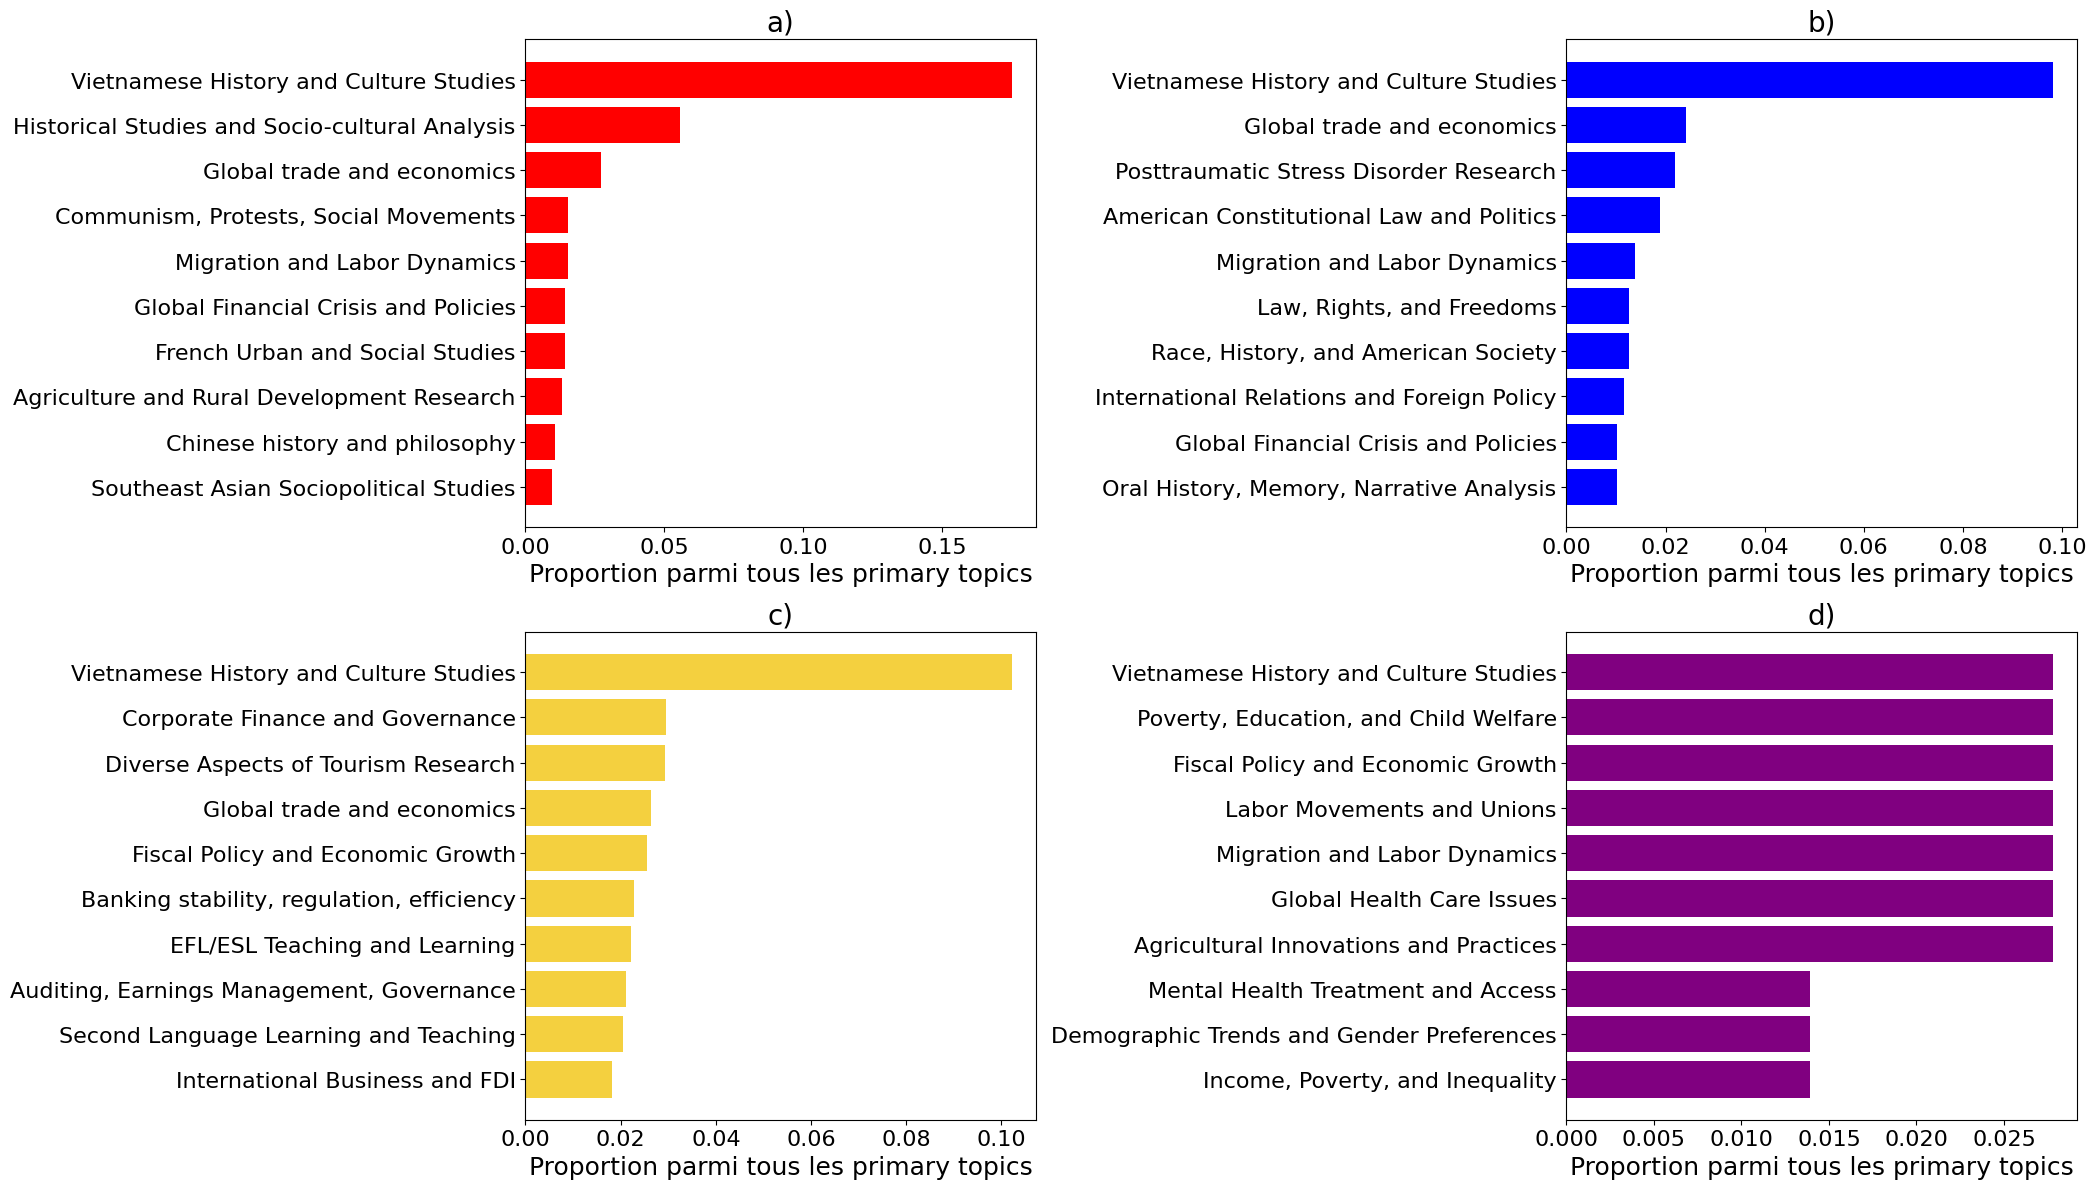

In [15]:
df['primary_topic_name_clean'] = df['primary_topic_name'].fillna("").str.strip()

df_fr = df[df['FR-US'] == 'FR']
df_us = df[df['FR-US'] == 'US']
df_vn = df[df['FR-US'] == 'VN']
df_fr_us = df[df['FR-US'] == 'FR-US']

def top10_props(df_subset):
    counts = df_subset['primary_topic_name_clean'].value_counts()
    props = (counts / counts.sum()).sort_values(ascending=False)
    return props.head(10)

top10_fr = top10_props(df_fr)
top10_us = top10_props(df_us)
top10_vn = top10_props(df_vn)
top10_fr_us = top10_props(df_fr_us)


title_fs = 20
label_fs = 18
tick_fs = 16

fig, axes = plt.subplots(2, 2, figsize=(21, 12))

plots = [
    (axes[0, 0], top10_fr, "a)", "red"),
    (axes[0, 1], top10_us, "b)", "blue"),
    (axes[1, 0], top10_vn, "c)", "#F4D03F"),
    (axes[1, 1], top10_fr_us, "d)", "purple"),
]

for ax, data, title, color in plots:
    ax.barh(data.index, data.values, color=color)
    ax.set_title(title, fontsize=title_fs)
    ax.set_xlabel("Proportion parmi tous les primary topics", fontsize=label_fs)
    ax.tick_params(axis='both', labelsize=tick_fs)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


## Vietnam War

In [16]:
df['Vietnam War'] = df['subfields'].fillna("").apply(
    lambda x: "Oui" if "Vietnam War" in str(x) else "Non"
)


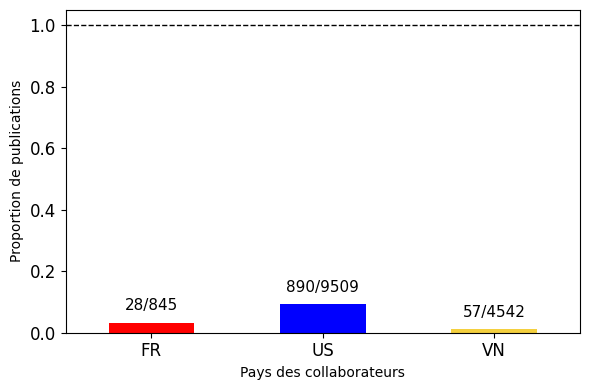

In [17]:
import matplotlib.pyplot as plt


df_filtered = df[df["FR-US"].isin(["FR", "US", "VN"])]


counts_total = df_filtered.groupby("FR-US")["Vietnam War"].count()
counts_yes = df_filtered.groupby("FR-US")["Vietnam War"].apply(lambda x: (x == "Oui").sum())

proportions = counts_yes / counts_total

colors = {
    "FR": "red",
    "US": "blue",
    "VN": "#F4D03F",
    "FR-US": "purple"
}
bar_colors = [colors[c] for c in proportions.index]

plt.figure(figsize=(6, 4))

bars = proportions.plot(kind="bar", color=bar_colors)

plt.axhline(1, color="black", linestyle="--", linewidth=1)

plt.title("")
plt.xlabel("Pays des collaborateurs")
plt.ylabel("Proportion de publications")

plt.ylim(0, 1.05)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

for i, country in enumerate(proportions.index):
    n_yes = counts_yes[country]
    n_total = counts_total[country]
    prop = proportions[country]

    plt.text(
        i,
        prop + 0.03,          
        f"{n_yes}/{n_total}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()
